In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv(r"C:\Users\Meghana\Downloads\customer-segmentation-project\Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [5]:
df.shape

(200, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Cluster                 200 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 9.5+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.400000
std,57.879185,13.969007,26.264721,25.823522,1.449311
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,1.000000
75%,150.250000,49.000000,78.000000,73.000000,3.000000
max,200.000000,70.000000,137.000000,99.000000,4.000000


In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64

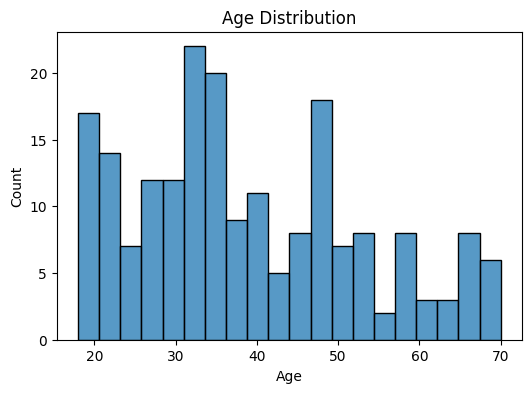

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

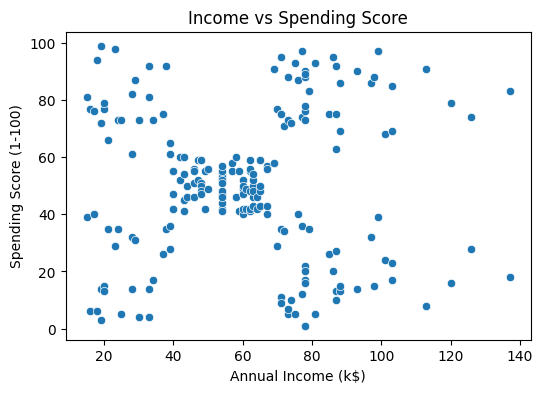

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

In [11]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

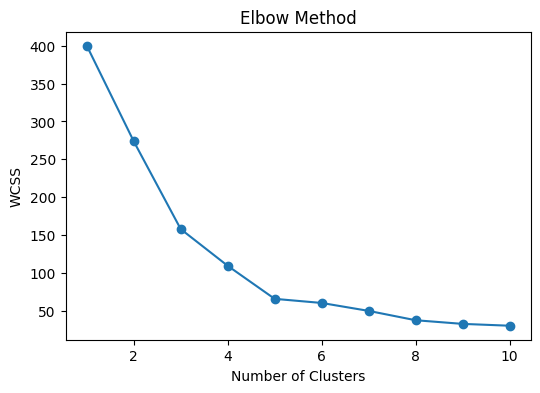

In [14]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

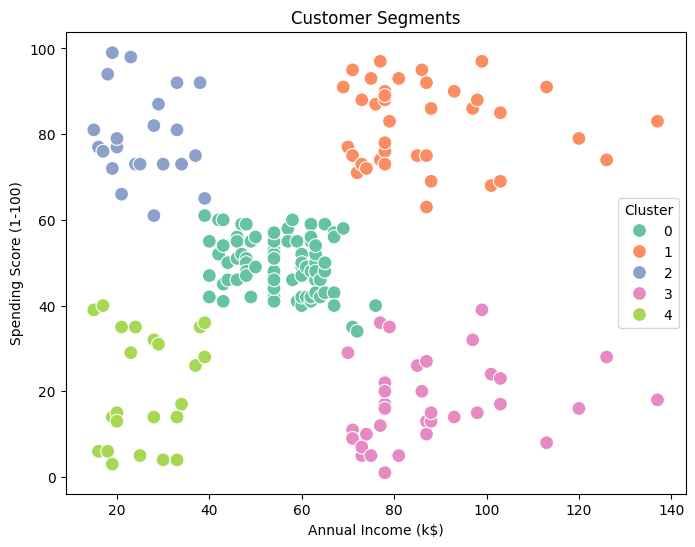

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    data=df,
    s=100
)

plt.title("Customer Segments")
plt.show()

# Customer Segment Insights

## Cluster 0
- High income and high spending customers
- Premium customer segment
- Ideal target for luxury products

## Cluster 1
- Low income and low spending
- Budget-conscious customers
- Less responsive to premium marketing

## Cluster 2
- High income but low spending
- Potential customers for targeted promotions

In [17]:
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [18]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [19]:
kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [20]:
df.to_csv(r"C:\Users\Meghana\Downloads\customer-segmentation-project\Mall_Customers.csv", index=False)

In [21]:
from sklearn.decomposition import PCA

In [22]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [23]:
pca_df = pd.DataFrame(
    data=pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['Cluster']

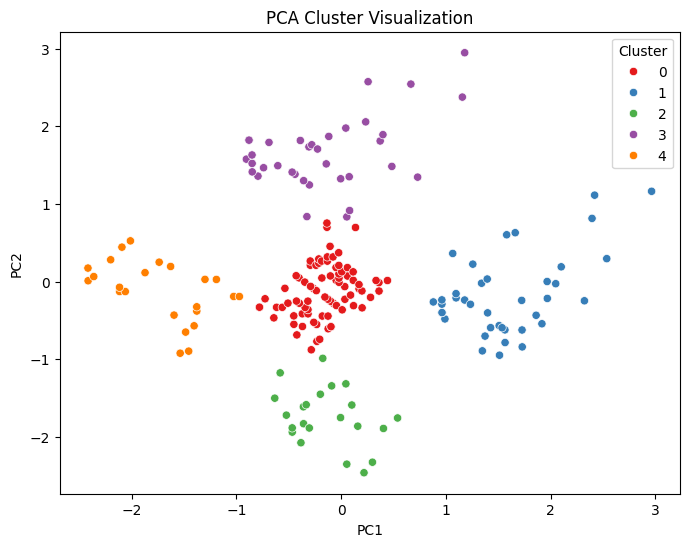

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("PCA Cluster Visualization")
plt.show()

In [25]:
from mpl_toolkits.mplot3d import Axes3D

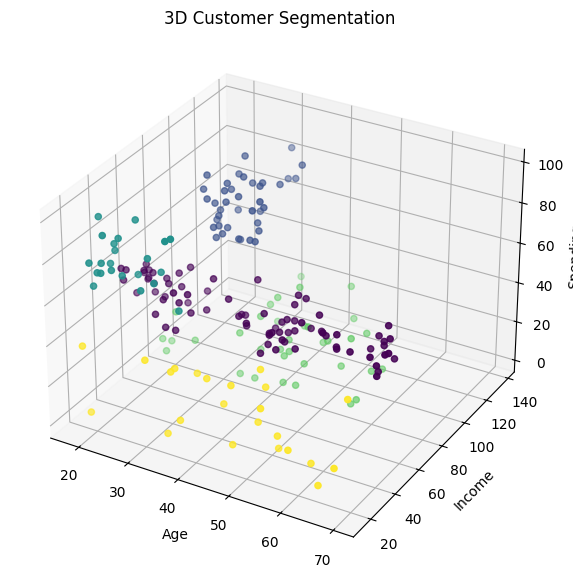

In [26]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Spending')

plt.title("3D Customer Segmentation")
plt.show()

In [27]:
strategies = {
    0: "Offer premium memberships",
    1: "Target with discounts",
    2: "Promote luxury products",
    3: "Retain with loyalty rewards",
    4: "Use personalized marketing"
}

In [28]:
df['Recommendation'] = df['Cluster'].map(strategies)

In [29]:
df[['Cluster', 'Recommendation']].head()

,Cluster,Recommendation
0,4,Use personalized marketing
1,2,Promote luxury products
2,4,Use personalized marketing
3,2,Promote luxury products
4,4,Use personalized marketing
